In [2]:
import numpy as np
import matplotlib.pyplot as plt

ValueError: x and y must have same first dimension, but have shapes (5000,) and (50,)

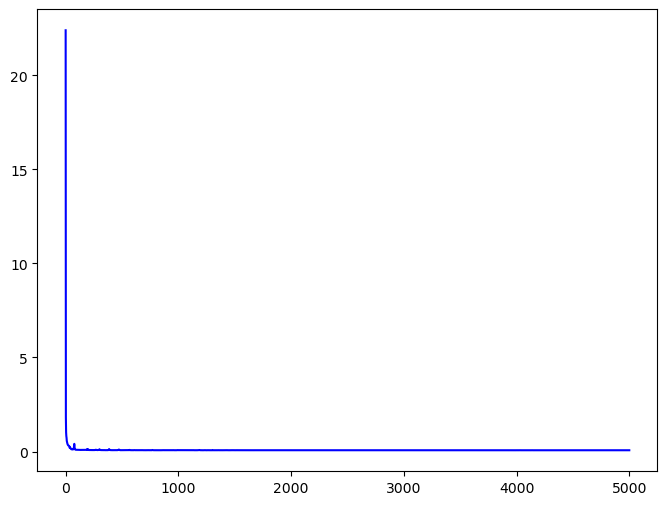

In [3]:
plt.figure(figsize=(8, 6))
train_loss = np.genfromtxt('./train_loss.txt')
test_loss = np.genfromtxt('./test_loss.txt')    
x = np.arange(len(train_loss))
plt.plot(x, train_loss, label='Train Loss', color='blue')
plt.plot(x, test_loss, label='Test Loss', color='orange')
plt.legend(loc='upper right')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
datafile = "Dimon_training_data_healthy.npz"
dataset = np.load(datafile, allow_pickle=True)

In [3]:
theta_all = dataset['theta']              # (105, 5)
pacing_all = dataset['pacing']            # (105, 4)
u_all = dataset['activation_times']       # (105, 48287)
x_data = dataset['reference_coords']      # (48287, 3)

In [4]:
theta_all.shape, u_all.shape, x_data.shape

((105, 5), (105, 48287), (48287, 3))

In [5]:
u_test = u_all[85:, :] 

In [6]:
u_all.shape, u_test.shape

((105, 48287), (20, 48287))

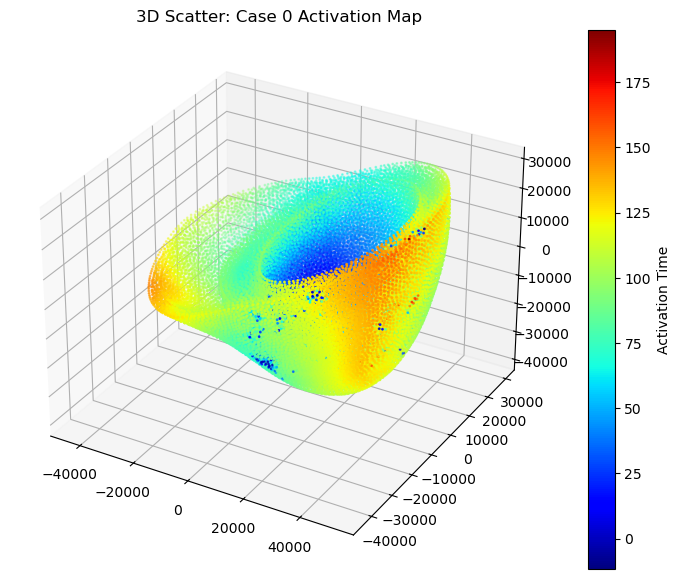

In [7]:
case_select = 41
u_case = u_all[case_select, :]

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# s=1 makes points small enough to see the shape without overlap
p = ax.scatter(x_data[:, 0], x_data[:, 1], x_data[:, 2], 
               c=u_case, cmap='jet', s=1)

fig.colorbar(p, label='Activation Time')
ax.set_title("3D Scatter: Case 0 Activation Map")
plt.show()

In [8]:
num_geomode = 5 
if_normal = 1 # Original code uses normalization
batch_size = 4 # Batch size to prevent CUDA OOM

dim_br_geo = [num_geomode, 200, 200, 200, 200]
dim_br_pace = [4, 200, 200, 200, 200]
dim_tr = [3, 200, 200, 200, 200]

num_train = 85
num_test = 20

## create folders
dump_train = './Predictions/Train/'
dump_test = './Predictions/Test/'
model_path = 'CheckPts/model_chkpts.pt'

## 1. Load Dataset from NPZ
datafile = "./dimon_training_data.npz"
dataset = np.load(datafile)

u_all = dataset['activation_times']       
theta_all = dataset['theta']              
pacing_all = dataset['pacing']            
x_data = dataset['reference_coords']      

u_scale = 1.0 # Standard physical scale (ms)

# 2. Split into Train/Test
u_train = u_all[:num_train, :]            
surf_train = theta_all[:num_train, :]     
x_pace_train = pacing_all[:num_train, :]  

u_test = u_all[num_train:, :]             
surf_test = theta_all[num_train:, :]      
x_pace_test = pacing_all[num_train:, :]    

num_pts = x_data.shape[0]
u_test_reshape_phy = u_test.reshape(-1, num_pts)
u_train_reshape_phy = u_train.reshape(-1, num_pts)

In [10]:
u_all.shape, u_test.shape, u_test_reshape_phy.shape

((105, 48287), (20, 48287), (20, 48287))